<a href="https://colab.research.google.com/github/vitor-laudares/Trabalho-Final-Py_Stellantis/blob/main/trabalho_final_py_stellantis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Trabalho final da disciplina de programação em Python

Alunos:

Anna Beatriz

Joao Pedro

Matheus Rocha

Pedro Henrique

Vitor Laudares


---




## Tema: Emissão de CO2 por veículos

O dataset escolhido, apresenta mais de 7 mil carros de diferentes montadoras. As características presentes são:

Make

Model

Vehicle Class

Engine Size(L)

Cylinders

Transmission

Fuel Type

Fuel Consumption City (L/100 km)

Fuel Consumption Hwy (L/100 km)

Fuel Consumption Comb (L/100 km)

Fuel Consumption Comb (mpg)

CO2 Emissions(g/km)

Vizualizações:

- Modelo que passou no limite x Valor do teste

- Grupo de marcas x Emissão

- Tipo de combustível x consumo estrada x consumo cidade

- Cambio x Eficiência

Histograma eficiencia energetica

dificuldades:encontrar a tradução dos códigos de combustivel


In [ ]:
# Imports e carregamento do arquivo
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
data = pd.read_csv('co2.csv')

# No data.info, vemos que não existem buracos nem dados faltantes
#data.info()


In [ ]:
total_antes = len(data)
data_temp = data.copy()

# Percorremos cada coluna e transformamos tudo para minúsculo
for coluna in data_temp.columns:
    data_temp[coluna] = data_temp[coluna].astype(str).str.lower()

duplicatas = data_temp.duplicated()

data = data[~duplicatas]

# Print do resultado
removidos = total_antes - len(data)
print(f"Foram removidos {removidos} registros duplicados.")


# Conversão de L/100km para km/L
colunas_consumo = ['Fuel Consumption City (L/100 km)',
                   'Fuel Consumption Hwy (L/100 km)',
                   'Fuel Consumption Comb (L/100 km)']
for coluna in colunas_consumo:
    data[coluna] = 100 / data[coluna]
    data.rename(columns={coluna: coluna.replace('L/100 km', 'km/L')}, inplace=True)
# data.info()


#Conversão dos Códigos de combustível
lista_combustiveis = []
for sigla in data['Fuel Type']:
    if sigla == 'D':
        lista_combustiveis.append('Diesel')
    elif sigla == 'E':
        lista_combustiveis.append('Etanol')
    elif sigla == 'N':
        lista_combustiveis.append('Gás Natural')
    elif sigla == 'X':
        lista_combustiveis.append('Gasolina Comum')
    elif sigla == 'Z':
        lista_combustiveis.append('Gasolina Premium')
    else:
        lista_combustiveis.append('Outros')
data['Fuel Type'] = lista_combustiveis


# Junção das marcas em grupos
stellantis_marcas = ['CHRYSLER', 'DODGE', 'FIAT', 'JEEP', 'RAM', 'ALFA ROMEO', 'MASERATI']
gm_marcas = ['CHEVROLET', 'BUICK', 'CADILLAC', 'GMC']
data.loc[data['Make'] == 'SRT', 'Make'] = 'DODGE'
lista_marcas = data['Make'].unique()

vw_marcas = ['VOLKSWAGEN', 'AUDI', 'PORSCHE', 'LAMBORGHINI', 'BENTLEY']
toyota_marcas = ['TOYOTA', 'LEXUS']
hyundai_marcas = ['HYUNDAI', 'KIA', 'GENESIS']
bmw_marcas = ['BMW', 'MINI', 'ROLLS-ROYCE']
ford_marcas = ['FORD', 'LINCOLN']
honda_marcas = ['HONDA', 'ACURA']




Foram removidos 1394 registros duplicados.


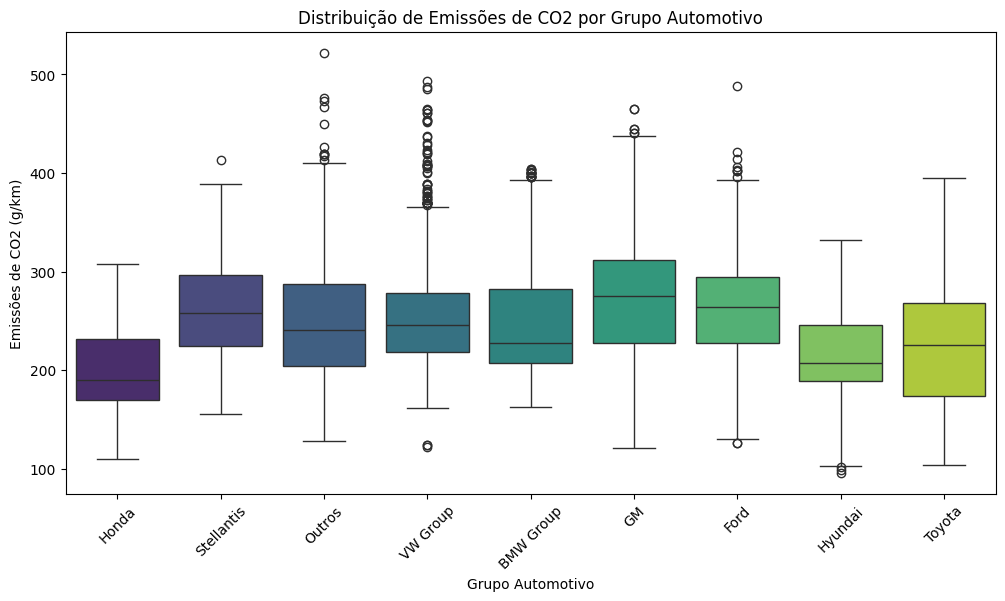

In [ ]:
lista_de_grupos = []
for marca in data['Make']:
    if marca in stellantis_marcas:
        lista_de_grupos.append('Stellantis')
    elif marca in gm_marcas:
        lista_de_grupos.append('GM')
    elif marca in vw_marcas:
        lista_de_grupos.append('VW Group')
    elif marca in toyota_marcas:
        lista_de_grupos.append('Toyota')
    elif marca in hyundai_marcas:
        lista_de_grupos.append('Hyundai')
    elif marca in bmw_marcas:
        lista_de_grupos.append('BMW Group')
    elif marca in ford_marcas:
        lista_de_grupos.append('Ford')
    elif marca in honda_marcas:
        lista_de_grupos.append('Honda')
    else:
        lista_de_grupos.append('Outros')

data['Grupo'] = lista_de_grupos

plt.figure(figsize=(12, 6))

sns.boxplot(
    x='Grupo',
    y='CO2 Emissions(g/km)',
    data=data,
    palette='viridis',
    hue='Grupo',
    legend=False
)

plt.title('Distribuição de Emissões de CO2 por Grupo Automotivo')
plt.xticks(rotation=45)
plt.xlabel('Grupo Automotivo')
plt.ylabel('Emissões de CO2 (g/km)')
plt.show()

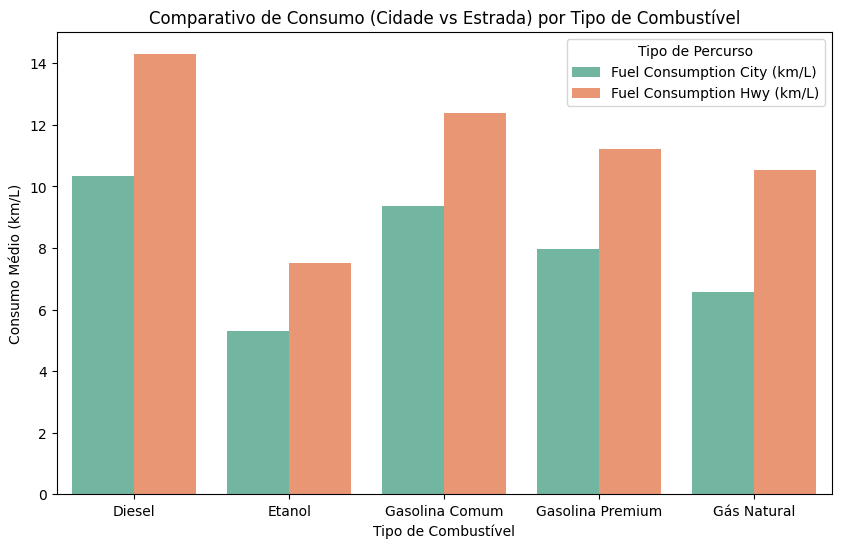

In [ ]:
dados_agrupados = data.groupby('Fuel Type')[['Fuel Consumption City (km/L)', 'Fuel Consumption Hwy (km/L)']].mean()

dados_agrupados = dados_agrupados.reset_index()

dados_longo = dados_agrupados.melt(id_vars='Fuel Type',
                                   value_vars=['Fuel Consumption City (km/L)', 'Fuel Consumption Hwy (km/L)'],
                                   var_name='Tipo de Percurso',
                                   value_name='Consumo (km/L)')

plt.figure(figsize=(10, 6))
sns.barplot(x='Fuel Type', y='Consumo (km/L)', hue='Tipo de Percurso', data=dados_longo, palette='Set2')

plt.title('Comparativo de Consumo (Cidade vs Estrada) por Tipo de Combustível')
plt.xlabel('Tipo de Combustível')
plt.ylabel('Consumo Médio (km/L)')
plt.show()

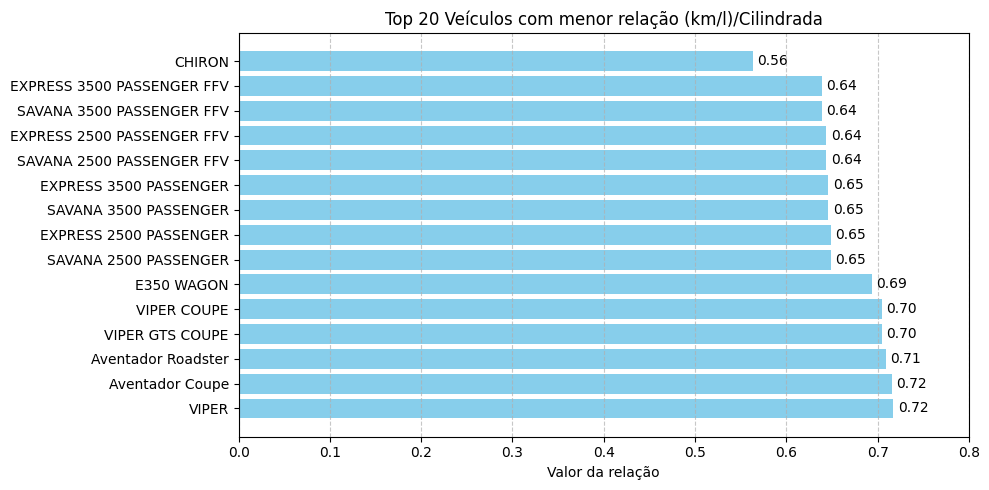

In [ ]:
data['EVE'] = data['Fuel Consumption Comb (km/L)'] / data['Engine Size(L)']

top_5 = data.nsmallest(15, 'EVE')
plt.figure(figsize=(10, 5))

plt.barh(top_5['Model'], top_5['EVE'], color='skyblue')

plt.xlabel('Valor da relação')
plt.title('Top 20 Veículos com menor relação (km/l)/Cilindrada')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xlim(0, 0.8)


for i, v in enumerate(top_5['EVE']):
    plt.text(v + 0.005, i, f"{v:.2f}", va='center')

plt.tight_layout()
plt.show()

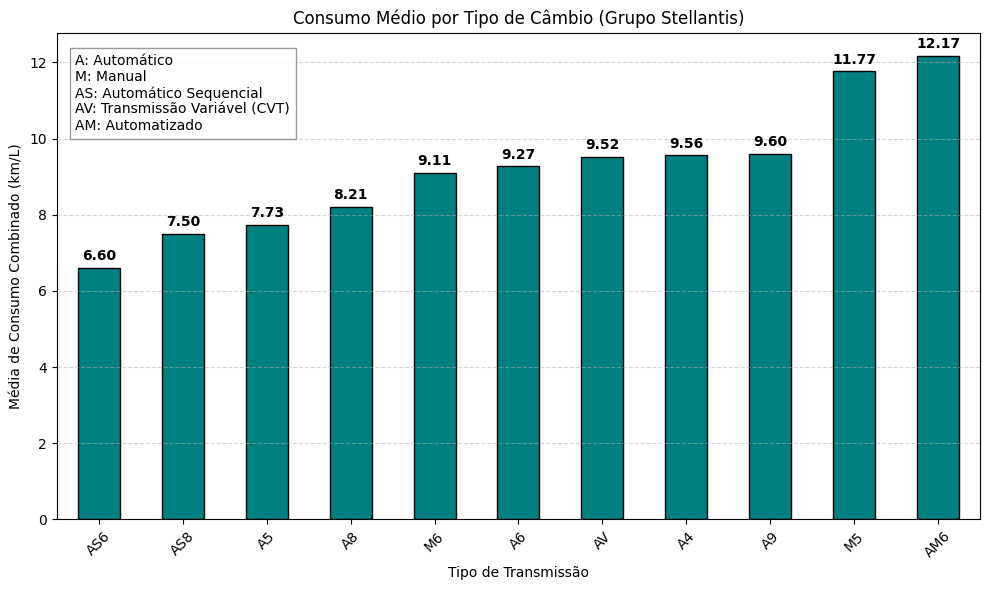

In [ ]:


legenda_cambio = {
    'A': 'Automático',
    'M': 'Manual',
    'AV': 'CVT (Transmissão Variável)',
    'AM': 'Automatizado',
    'AS': 'Automático com modo sequencial'
}


data['Make_Lower'] = data['Make'].str.upper()
df_stellantis = data[data['Make_Lower'].isin(stellantis_marcas)]

media_cambio = df_stellantis.groupby('Transmission')['Fuel Consumption Comb (km/L)'].mean().sort_values()

plt.figure(figsize=(10, 6))

media_cambio.plot(kind='bar', color='teal', edgecolor='black', rot=45)

plt.title('Consumo Médio por Tipo de Câmbio (Grupo Stellantis)')
plt.ylabel('Média de Consumo Combinado (km/L)')
plt.xlabel('Tipo de Transmissão')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, v in enumerate(media_cambio):

    plt.text(i, v + 0.2, f"{v:.2f}", ha='center', fontweight='bold')

legenda_explicativa = (
    "A: Automático\nM: Manual\nAS: Automático Sequencial\n"
    "AV: Transmissão Variável (CVT)\nAM: Automatizado"
)


plt.text(0.02, 0.80, legenda_explicativa,
         transform=plt.gca().transAxes,
         fontsize=10,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
plt.tight_layout()
plt.show()

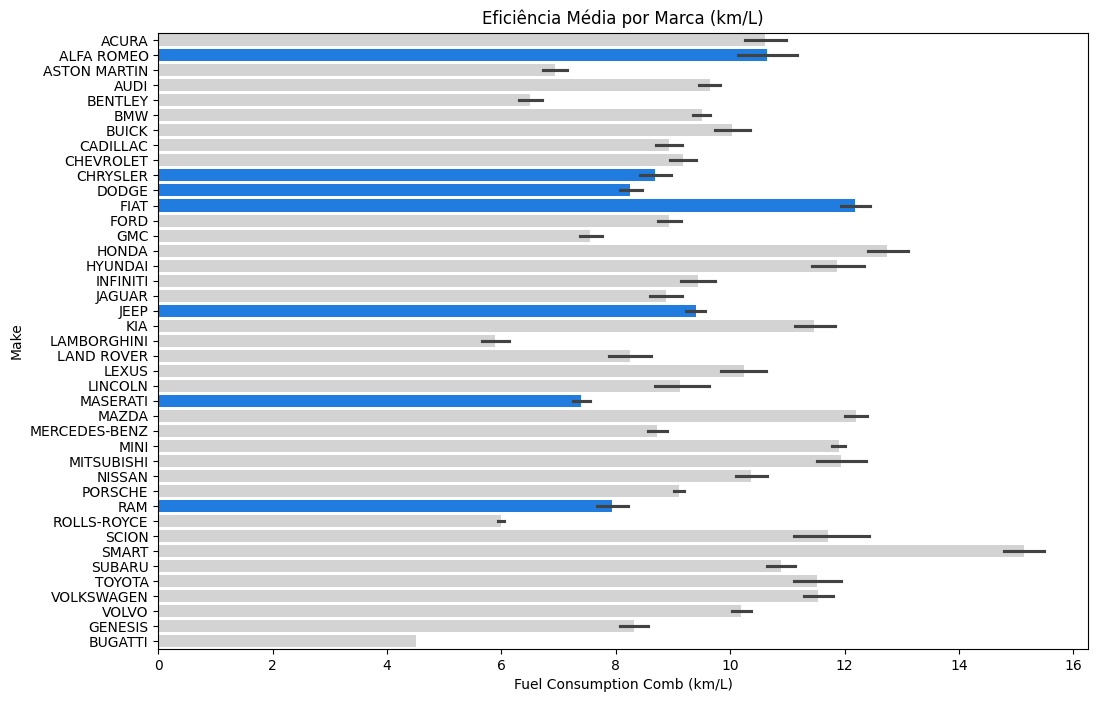

In [ ]:
# cores = {}
# # Percorre a lista de marcas
# for marca in lista_marcas:
#     # Aplica a verificação se a marca está no grupo stellantes
#     if marca in stellantis_marcas:
#         cores[marca] = '#007bff'  # Cor Stellantis
#     else:
#         cores[marca] = '#d3d3d3'  # Cor Cinza (outras marcas)
# plt.figure(figsize=(12, 8))
# sns.barplot(
#     data=data,
#     x='Fuel Consumption Comb (km/L)',
#     y='Make',
#     hue='Make',
#     palette=cores,
#     legend=False
# )

# plt.title('Eficiência Média por Marca (km/L)')
# plt.show()


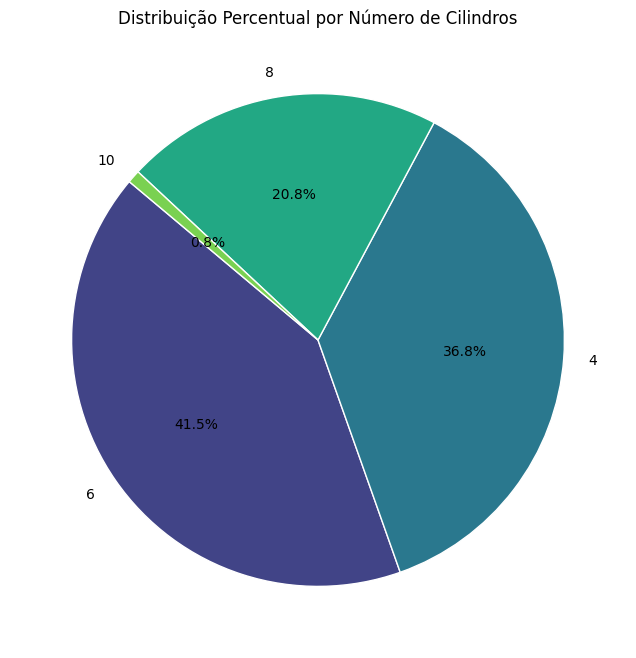

In [ ]:
contagem_cilindros = df_stellantis['Cylinders'].value_counts()

plt.figure(figsize=(8, 8))
contagem_cilindros.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('viridis', len(contagem_cilindros)),
    wedgeprops={'edgecolor': 'white'}
)

plt.title('Distribuição Percentual por Número de Cilindros')
plt.ylabel('')
plt.show()